# XGBoost + Optuna 지하철 2호선 승하차 예측 + 날씨 SHAP 영향도 분석

## 개요
- **데이터**: 2년치 서울 지하철 2호선 51개 역 시간대별 승하차 + 기상청 날씨
- **타깃**: 승차인원, 하차인원 (모델 2개 독립 학습)
- **시계열 분할**: 마지막 2개월 검증, 나머지 학습
- **핵심 추가**: Optuna로 최적 하이퍼파라미터 자동 탐색 → SHAP 날씨 영향도 분석

### 전체 흐름
```
1~5번  기존과 동일 (라이브러리, 데이터, 피처, 분할, 피처정의)
6번    Optuna 하이퍼파라미터 탐색  ← NEW
7번    최적 파라미터로 최종 모델 학습  ← NEW
8~14번 기존과 동일 (예측, 평가, 시각화, SHAP, 저장, 추론)
```

### `final_dataset2.csv` 컬럼
| 컬럼 | 설명 |
|------|------|
| 날짜 | datetime |
| 역명 | 2호선 51개 역 |
| 시간 | 5 ~ 23 (정수) |
| 승차인원 / 하차인원 | **타깃** |
| 요일 | 0(월) ~ 6(일) |
| 월 | 1 ~ 12 |
| 공휴일여부 | 0 / 1 |
| 기온 | °C |
| 강수량 / 적설 | mm |


## 1. 라이브러리 로드

In [1]:
!pip install shap optuna -q
!apt-get install -y -q fonts-nanum

import matplotlib as mpl
import matplotlib.font_manager as fm

# 폰트 캐시 강제 갱신
fm.fontManager.__init__()
fm._load_fontmanager(try_read_cache=False)

# 나눔 폰트 경로 직접 등록
nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(nanum_path)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap
import optuna
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)  # optuna 로그 최소화

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib, os

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("등록된 폰트:", [f.name for f in fm.fontManager.ttflist if "Nanum" in f.name])
print("라이브러리 로드 완료")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.8 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (80.1 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
등록된 폰트: ['NanumGothic', 'NanumGothicCoding', 'NanumBarunGothic', 'NanumSquare', 'NanumMyeongjo', 'NanumSquareRound', 'NanumMyeongjo', 'NanumSquare', 'NanumBa

## 2. 데이터 로드

In [2]:
from google.colab import drive
drive.mount("/content/drive")

df = pd.read_csv("/content/drive/MyDrive/final_dataset2.csv", parse_dates=["날짜"])
print(f"데이터 로드 완료: {len(df):,}행 × {df.shape[1]}열")
print(f"기간: {df['날짜'].min().date()} ~ {df['날짜'].max().date()}")
df.head()


Mounted at /content/drive
데이터 로드 완료: 731,000행 × 12열
기간: 2023-01-01 ~ 2025-01-01


,날짜,역명,호선,승차인원,시간,하차인원,요일,월,공휴일여부,기온,강수량,적설
0,2023-01-01,시청,2호선,43,5,36,6,1,1,0.8,0.0,0.0
1,2023-01-01,을지로입구,2호선,108,5,114,6,1,1,0.8,0.0,0.0
2,2023-01-01,을지로3가,2호선,52,5,55,6,1,1,0.8,0.0,0.0
3,2023-01-01,을지로4가,2호선,21,5,37,6,1,1,0.8,0.0,0.0
4,2023-01-01,동대문역사문화공원(DDP),2호선,63,5,49,6,1,1,0.8,0.0,0.0


## 3. 피처 엔지니어링

| 추가 피처 | 이유 |
|-----------|------|
| 시간/월/요일 sin·cos | 순환성 표현 (23시 → 0시 연속성) |
| 출근·퇴근 피크 플래그 | 도메인 지식 명시 주입 |
| 비근무일 | 주말 + 공휴일 통합 |
| 강수·적설 여부 | 희소값(0이 94%)의 이진화 |
| 불쾌지수 | 기온 + 강수 복합 날씨 효과 |
| 역명 LabelEncoding | XGBoost는 범주형 직접 입력 불가 |


In [3]:
df = df.sort_values(["날짜", "역명", "시간"]).reset_index(drop=True)

# 역명 인코딩
le_station     = LabelEncoder()
df["역명_enc"] = le_station.fit_transform(df["역명"])

# 시간 주기 인코딩
df["시간_sin"] = np.sin(2 * np.pi * df["시간"] / 24)
df["시간_cos"] = np.cos(2 * np.pi * df["시간"] / 24)

# 월 주기 인코딩
df["월_sin"]   = np.sin(2 * np.pi * df["월"] / 12)
df["월_cos"]   = np.cos(2 * np.pi * df["월"] / 12)

# 요일 주기 인코딩
df["요일_sin"] = np.sin(2 * np.pi * df["요일"] / 7)
df["요일_cos"] = np.cos(2 * np.pi * df["요일"] / 7)

# 날씨 파생 피처
df["강수_여부"] = (df["강수량"] > 0).astype(int)
df["적설_여부"] = (df["적설"]   > 0).astype(int)
df["불쾌지수"]  = (
    9/5 * df["기온"]
    - 0.55 * (1 - df["강수_여부"] * 0.8) * (9/5 * df["기온"] - 26)
    + 32
).round(2)

# 통합 플래그
df["비근무일"] = ((df["요일"] >= 5) | (df["공휴일여부"] == 1)).astype(int)
df["출근피크"] = df["시간"].isin([7, 8, 9]).astype(int)
df["퇴근피크"] = df["시간"].isin([18, 19, 20]).astype(int)

print(f"피처 엔지니어링 완료 — 총 컬럼 수: {df.shape[1]}")
df[["역명","시간","시간_sin","시간_cos","강수_여부","불쾌지수","비근무일","출근피크","퇴근피크"]].head(3)

# ── 방법 1: 공휴일 종류 세분화 ──────────────────────────
import holidays as hd

kr_hols = hd.KR(years=df["날짜"].dt.year.unique().tolist())

def get_holiday_type(date):
    if date.date() not in kr_hols:
        return 0
    name = kr_hols.get(date.date(), "")

    # 설날/추석 연휴 (귀성·귀경 인파)
    if any(k in name for k in [
        "Korean New Year", "Chuseok", "preceding Korean", "preceding Chuseok",
        "second day of Korean", "second day of Chuseok"
    ]):
        return 3

    # 가족·나들이형 공휴일
    elif any(k in name for k in [
        "Children", "Christmas", "Buddha", "Alternative holiday for Buddha"
    ]):
        return 2

    # 일반 공휴일 (광복절, 개천절, 한글날 등)
    else:
        return 1

df["공휴일_유형"] = df["날짜"].apply(get_holiday_type)

# 연휴 여부 (앞뒤 공휴일/주말과 이어지는지)
def is_long_holiday(date):
    prev_day = date - pd.Timedelta(days=1)
    next_day = date + pd.Timedelta(days=1)
    prev_off = (prev_day.weekday() >= 5) or (prev_day.date() in kr_hols)
    next_off = (next_day.weekday() >= 5) or (next_day.date() in kr_hols)
    is_off   = (date.weekday() >= 5) or (date.date() in kr_hols)
    return int(is_off and (prev_off or next_off))

df["연휴_여부"] = df["날짜"].apply(is_long_holiday)


# ── 방법 2: 공휴일 전날/다음날 플래그 ────────────────────
hol_dates = set(kr_hols.keys())

def is_pre_holiday(date):
    next_day = (date + pd.Timedelta(days=1)).date()
    return int(next_day in hol_dates)

def is_post_holiday(date):
    prev_day = (date - pd.Timedelta(days=1)).date()
    return int(prev_day in hol_dates)

df["공휴일_전날"]  = df["날짜"].apply(is_pre_holiday)
df["공휴일_다음날"] = df["날짜"].apply(is_post_holiday)

print(f"공휴일 유형 분포:\n{df['공휴일_유형'].value_counts().sort_index()}")
print(f"\n연휴_여부    1인 행: {df['연휴_여부'].sum():,}")
print(f"공휴일_전날  1인 행: {df['공휴일_전날'].sum():,}")
print(f"공휴일_다음날 1인 행: {df['공휴일_다음날'].sum():,}")


피처 엔지니어링 완료 — 총 컬럼 수: 25
공휴일 유형 분포:
공휴일_유형
0    694000
1     15000
2      8000
3     14000
Name: count, dtype: int64

연휴_여부    1인 행: 226,950
공휴일_전날  1인 행: 37,000
공휴일_다음날 1인 행: 37,000


## 4. 시계열 분할

> **랜덤 분할 금지** — 데이터 누수(Data Leakage) 방지
> 마지막 2개월을 검증, 나머지를 학습으로 자동 분리


In [4]:
max_date   = df["날짜"].max()
split_date = max_date - pd.DateOffset(months=2)
split_date = split_date.replace(day=1)   # 월 첫째 날로 정렬

train_df = df[df["날짜"] < split_date].copy()
valid_df = df[df["날짜"] >= split_date].copy()

print(f"분할 기준일 : {split_date.date()}")
print(f"학습: {len(train_df):>10,}행  ({train_df['날짜'].min().date()} ~ {train_df['날짜'].max().date()})")
print(f"검증: {len(valid_df):>10,}행  ({valid_df['날짜'].min().date()} ~ {valid_df['날짜'].max().date()})")
print(f"분할 비율 — 학습 {len(train_df)/len(df)*100:.1f}% / 검증 {len(valid_df)/len(df)*100:.1f}%")


분할 기준일 : 2024-11-01
학습:    669,950행  (2023-01-01 ~ 2024-10-31)
검증:     61,050행  (2024-11-01 ~ 2025-01-01)
분할 비율 — 학습 91.6% / 검증 8.4%


## 5. 피처 / 타깃 정의

In [5]:
FEATURE_COLS = [
    "역명_enc",
    "시간",   "시간_sin",  "시간_cos",
    "요일",   "요일_sin",  "요일_cos",
    "월",     "월_sin",    "월_cos",
    "공휴일여부", "비근무일",
    "출근피크", "퇴근피크",
    "기온", "강수량", "적설",
    "강수_여부", "적설_여부", "불쾌지수",
    # ── 추가 ──
    "공휴일_유형",    # 공휴일 종류 (0~3)
    "연휴_여부",      # 연휴 연결 여부
    "공휴일_전날",    # 내일이 공휴일
    "공휴일_다음날",  # 어제가 공휴일
]
TARGET_COLS = ["승차인원", "하차인원"]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COLS]
X_valid = valid_df[FEATURE_COLS]
y_valid = valid_df[TARGET_COLS]

print(f"피처 수 : {len(FEATURE_COLS)}")
print(f"타깃    : {TARGET_COLS}")
print(f"X_train : {X_train.shape}  /  X_valid : {X_valid.shape}")


피처 수 : 24
타깃    : ['승차인원', '하차인원']
X_train : (669950, 24)  /  X_valid : (61050, 24)


## 6. Optuna 하이퍼파라미터 탐색

### 탐색 범위 설명

| 파라미터 | 탐색 범위 | 방식 |
|----------|-----------|------|
| `n_estimators` | 300 ~ 3000 | 정수 탐색 |
| `learning_rate` | 0.005 ~ 0.3 | 로그 스케일 (작은 값 집중 탐색) |
| `max_depth` | 3 ~ 10 | 정수 탐색 |
| `min_child_weight` | 1 ~ 30 | 정수 탐색 |
| `subsample` | 0.5 ~ 1.0 | 소수 탐색 |
| `colsample_bytree` | 0.5 ~ 1.0 | 소수 탐색 |
| `reg_alpha` | 1e-8 ~ 10 | 로그 스케일 |
| `reg_lambda` | 1e-8 ~ 10 | 로그 스케일 |
| `gamma` | 1e-8 ~ 1.0 | 로그 스케일 |




In [8]:
import os, joblib
os.makedirs("models", exist_ok=True)
print("models 폴더 준비 완료")

models 폴더 준비 완료


In [9]:
# ── 탐색 횟수 설정 ──
N_TRIALS = 100

def objective(trial, target_col):
    params = dict(
        n_estimators          = trial.suggest_int("n_estimators", 300, 3000),
        learning_rate         = trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth             = trial.suggest_int("max_depth", 3, 10),
        min_child_weight      = trial.suggest_int("min_child_weight", 1, 30),
        subsample             = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree      = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha             = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda            = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        gamma                 = trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        tree_method           = "hist",
        device                = "cuda",
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
        early_stopping_rounds = 30,
        eval_metric           = "mae",
    )

    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train[target_col],
        eval_set=[(X_valid, y_valid[target_col])],
        verbose=False,
    )
    pred = np.clip(model.predict(X_valid), 0, None)
    return mean_absolute_error(y_valid[target_col], pred)


# ── 승차인원 탐색 ──
print(f"승차인원 Optuna 탐색 시작 ({N_TRIALS} trials)...")
study_board = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.NopPruner(),  # ← 변경
)
study_board.optimize(
    lambda trial: objective(trial, "승차인원"),
    n_trials=N_TRIALS,
    show_progress_bar=True,
    callbacks=[
        lambda study, trial: joblib.dump(study, "models/optuna_study_board.pkl")
        if trial.number % 10 == 0 else None  # 10 trials마다 저장
    ],
)

print(f"\n  최적 MAE  : {study_board.best_value:,.2f} 명")
print(f"  최적 trial: {study_board.best_trial.number}")
print(f"  최적 파라미터:")
for k, v in study_board.best_params.items():
    print(f"    {k:<22}: {v}")


# ── 하차인원 탐색 ──
print(f"\n하차인원 Optuna 탐색 시작 ({N_TRIALS} trials)...")
study_alight = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.NopPruner(),  # ← 변경
)
study_alight.optimize(
    lambda trial: objective(trial, "하차인원"),
    n_trials=N_TRIALS,
    show_progress_bar=True,
    callbacks=[
        lambda study, trial: joblib.dump(study, "models/optuna_study_alight.pkl")
        if trial.number % 10 == 0 else None  # 10 trials마다 저장
    ],
)

print(f"\n  최적 MAE  : {study_alight.best_value:,.2f} 명")
print(f"  최적 trial: {study_alight.best_trial.number}")
print(f"  최적 파라미터:")
for k, v in study_alight.best_params.items():
    print(f"    {k:<22}: {v}")

승차인원 Optuna 탐색 시작 (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


  최적 MAE  : 116.59 명
  최적 trial: 77
  최적 파라미터:
    n_estimators          : 1856
    learning_rate         : 0.029856922360439377
    max_depth             : 10
    min_child_weight      : 13
    subsample             : 0.8940890108197588
    colsample_bytree      : 0.9303636364348911
    reg_alpha             : 1.804608835556307e-08
    reg_lambda            : 0.25819485237637657
    gamma                 : 1.873712265835856e-06

하차인원 Optuna 탐색 시작 (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


  최적 MAE  : 123.86 명
  최적 trial: 79
  최적 파라미터:
    n_estimators          : 1284
    learning_rate         : 0.031264997548181586
    max_depth             : 10
    min_child_weight      : 2
    subsample             : 0.9282831547844993
    colsample_bytree      : 0.8225331637290082
    reg_alpha             : 0.0005479595001795172
    reg_lambda            : 2.957788854536092
    gamma                 : 0.1627858994752026


### 6-1. Optuna 탐색 결과 시각화

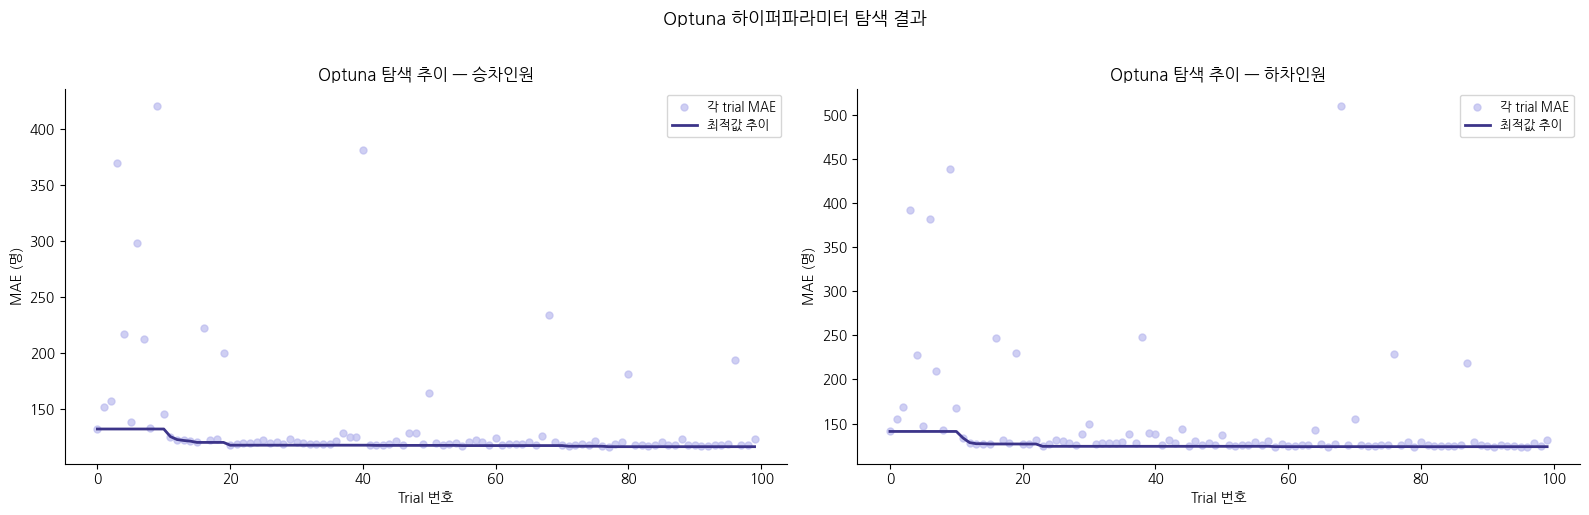

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, study, label in zip(axes, [study_board, study_alight], TARGET_COLS):
    trials     = study.trials
    trial_nums = [t.number for t in trials if t.value is not None]
    maes       = [t.value  for t in trials if t.value is not None]
    best_so_far = []
    cur_best = float("inf")
    for v in maes:
        cur_best = min(cur_best, v)
        best_so_far.append(cur_best)

    ax.scatter(trial_nums, maes, color="#BBBBEE", s=25, alpha=0.7, label="각 trial MAE")
    ax.plot(trial_nums, best_so_far, color="#3C3489", linewidth=2, label="최적값 추이")
    ax.set_title(f"Optuna 탐색 추이 — {label}", fontsize=12)
    ax.set_xlabel("Trial 번호", fontsize=10)
    ax.set_ylabel("MAE (명)", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Optuna 하이퍼파라미터 탐색 결과", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()


### 6-2. 파라미터 중요도

> 어떤 파라미터를 바꿨을 때 MAE가 가장 많이 달라졌는지 보여줍니다.
> 중요도가 높은 파라미터일수록 튜닝 효과가 크다는 뜻이에요.


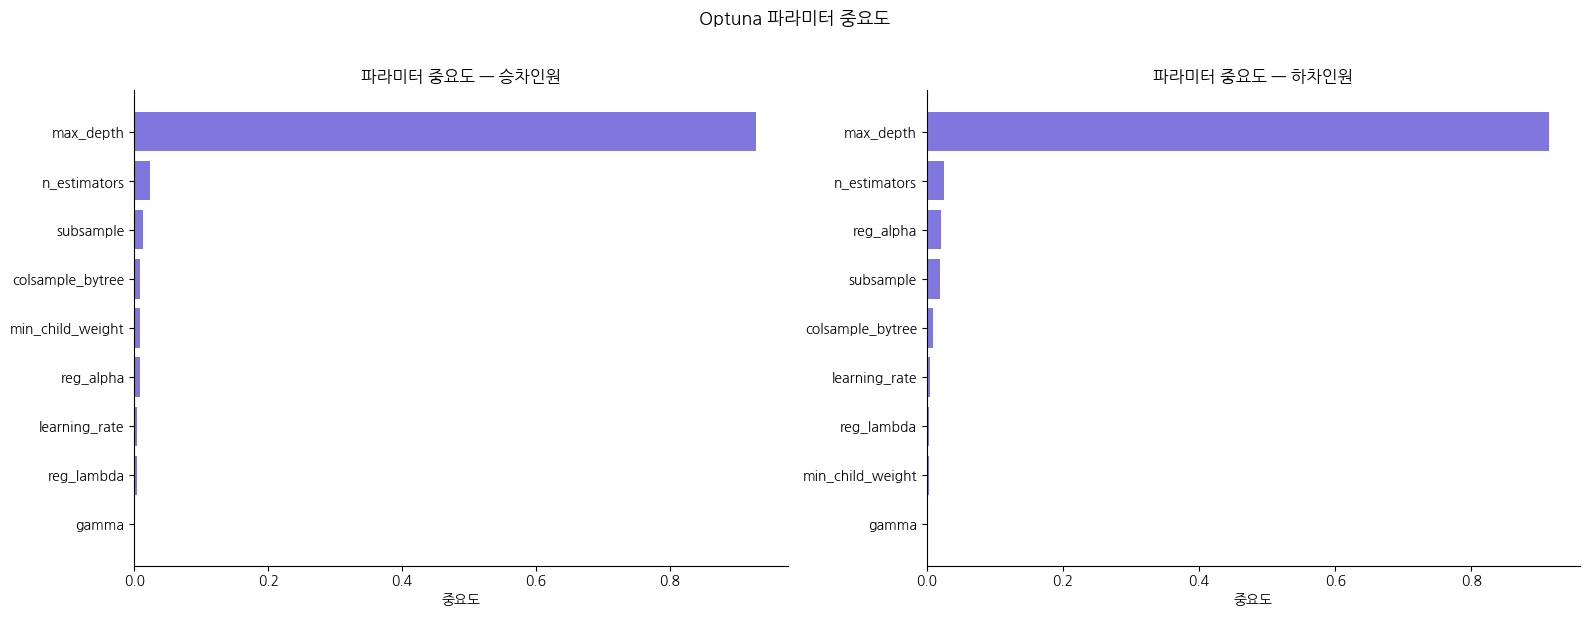

In [11]:
from optuna.importance import get_param_importances

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, study, label in zip(axes, [study_board, study_alight], TARGET_COLS):
    try:
        importances = get_param_importances(study)
        params_sorted = sorted(importances.items(), key=lambda x: x[1])
        names  = [p[0] for p in params_sorted]
        values = [p[1] for p in params_sorted]

        ax.barh(names, values, color="#7F77DD", edgecolor="none")
        ax.set_title(f"파라미터 중요도 — {label}", fontsize=12)
        ax.set_xlabel("중요도", fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
    except Exception as e:
        msg = f"계산 불가 (trials 부족)\n{str(e)}"
        ax.text(0.5, 0.5, msg, ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Optuna 파라미터 중요도", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("optuna_param_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 최적 파라미터로 최종 모델 학습

> Optuna가 찾은 최적 파라미터로 최종 모델을 학습합니다.
> 기존 수동 설정 파라미터와 성능을 비교합니다.


In [12]:
# ── 최적 파라미터 추출 ──
best_params_board  = study_board.best_params
best_params_alight = study_alight.best_params

# tree_method, random_state, n_jobs 고정값 추가
fixed = dict(tree_method="hist", device="cuda", random_state=42, n_jobs=-1, verbosity=0)
best_params_board.update(fixed)
best_params_alight.update(fixed)

# ── 최종 모델 학습 ──
print("승차인원 최종 모델 학습 중...")
model_board = XGBRegressor(**best_params_board, early_stopping_rounds=30, eval_metric="mae")
model_board.fit(
    X_train, y_train["승차인원"],
    eval_set=[(X_valid, y_valid["승차인원"])],
    verbose=False,
)
print(f"  best iteration: {model_board.best_iteration}")

print("하차인원 최종 모델 학습 중...")
model_alight = XGBRegressor(**best_params_alight, early_stopping_rounds=30, eval_metric="mae")
model_alight.fit(
    X_train, y_train["하차인원"],
    eval_set=[(X_valid, y_valid["하차인원"])],
    verbose=False,
)
print(f"  best iteration: {model_alight.best_iteration}")

print("최종 모델 학습 완료")

승차인원 최종 모델 학습 중...
  best iteration: 1113
하차인원 최종 모델 학습 중...
  best iteration: 930
최종 모델 학습 완료


## 8. 예측 (음수 클리핑 포함)

In [13]:
y_pred = pd.DataFrame({
    "승차인원": np.clip(model_board.predict(X_valid),  0, None),
    "하차인원": np.clip(model_alight.predict(X_valid), 0, None),
}, index=y_valid.index)

sample              = valid_df[["날짜", "역명", "시간"]].copy()
sample["실제_승차"] = y_valid["승차인원"].values
sample["예측_승차"] = y_pred["승차인원"].values.astype(int)
sample["실제_하차"] = y_valid["하차인원"].values
sample["예측_하차"] = y_pred["하차인원"].values.astype(int)
sample.head(10)


,날짜,역명,시간,실제_승차,예측_승차,실제_하차,예측_하차
669950,2024-11-01,강남,0,644,642,357,339
669951,2024-11-01,강남,5,321,274,489,449
669952,2024-11-01,강남,6,693,646,2408,2267
669953,2024-11-01,강남,7,1719,1626,6803,6375
669954,2024-11-01,강남,8,2638,2641,13865,12853
669955,2024-11-01,강남,9,1956,1984,12146,12422
669956,2024-11-01,강남,10,2032,1937,5516,5851
669957,2024-11-01,강남,11,2623,2535,3845,3717
669958,2024-11-01,강남,12,3140,3247,3282,3373
669959,2024-11-01,강남,13,3572,3761,4024,3870


## 9. 평가 지표 (MAE / RMSE / MAPE)

In [14]:
def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("=" * 55)
print(f"  검증 성능  ({valid_df['날짜'].min().date()} ~ {valid_df['날짜'].max().date()})")
print("=" * 55)

# 기존 수동 파라미터 성능 (비교용)
PREV_MAE = {"승차인원": 150.9, "하차인원": 162.3}

for col, estimator in zip(TARGET_COLS, [model_board, model_alight]):
    actual   = y_valid[col]
    pred     = y_pred[col]
    mae      = mean_absolute_error(actual, pred)
    rmse     = np.sqrt(mean_squared_error(actual, pred))
    mape_val = mape(actual, pred)
    improve  = PREV_MAE[col] - mae

    print(f"[{col}]")
    print(f"MAE   : {mae:,.1f} 명  (기존 {PREV_MAE[col]:.1f} → {'▼' if improve > 0 else '▲'}{abs(improve):.1f} 명 {'개선' if improve > 0 else '악화'})")
    print(f"RMSE  : {rmse:,.1f} 명")
    print(f"MAPE  : {mape_val:.2f} %")

print("=" * 55)

# 시간대별 MAPE (새벽 vs 피크 비교)
print("시간대별 승차 MAPE:")
for hr in [5, 6, 7, 8, 9, 12, 18, 19, 20, 23]:
    mask = valid_df["시간"] == hr
    m = mape(y_valid.loc[mask, "승차인원"], y_pred.loc[mask, "승차인원"])
    bar = "█" * int(m / 5)
    print(f"    {hr:2d}시: {m:5.1f}%  {bar}")


  검증 성능  (2024-11-01 ~ 2025-01-01)
[승차인원]
MAE   : 116.6 명  (기존 150.9 → ▼34.3 명 개선)
RMSE  : 241.2 명
MAPE  : 23.87 %
[하차인원]
MAE   : 123.9 명  (기존 162.3 → ▼38.4 명 개선)
RMSE  : 243.4 명
MAPE  : 19.22 %
시간대별 승차 MAPE:
     5시:  20.1%  ████
     6시:  12.6%  ██
     7시:  12.5%  ██
     8시:   9.6%  █
     9시:   8.8%  █
    12시:   9.4%  █
    18시:  12.3%  ██
    19시:  14.9%  ██
    20시:  16.3%  ███
    23시:  38.3%  ███████


## 10. 피처 중요도 시각화

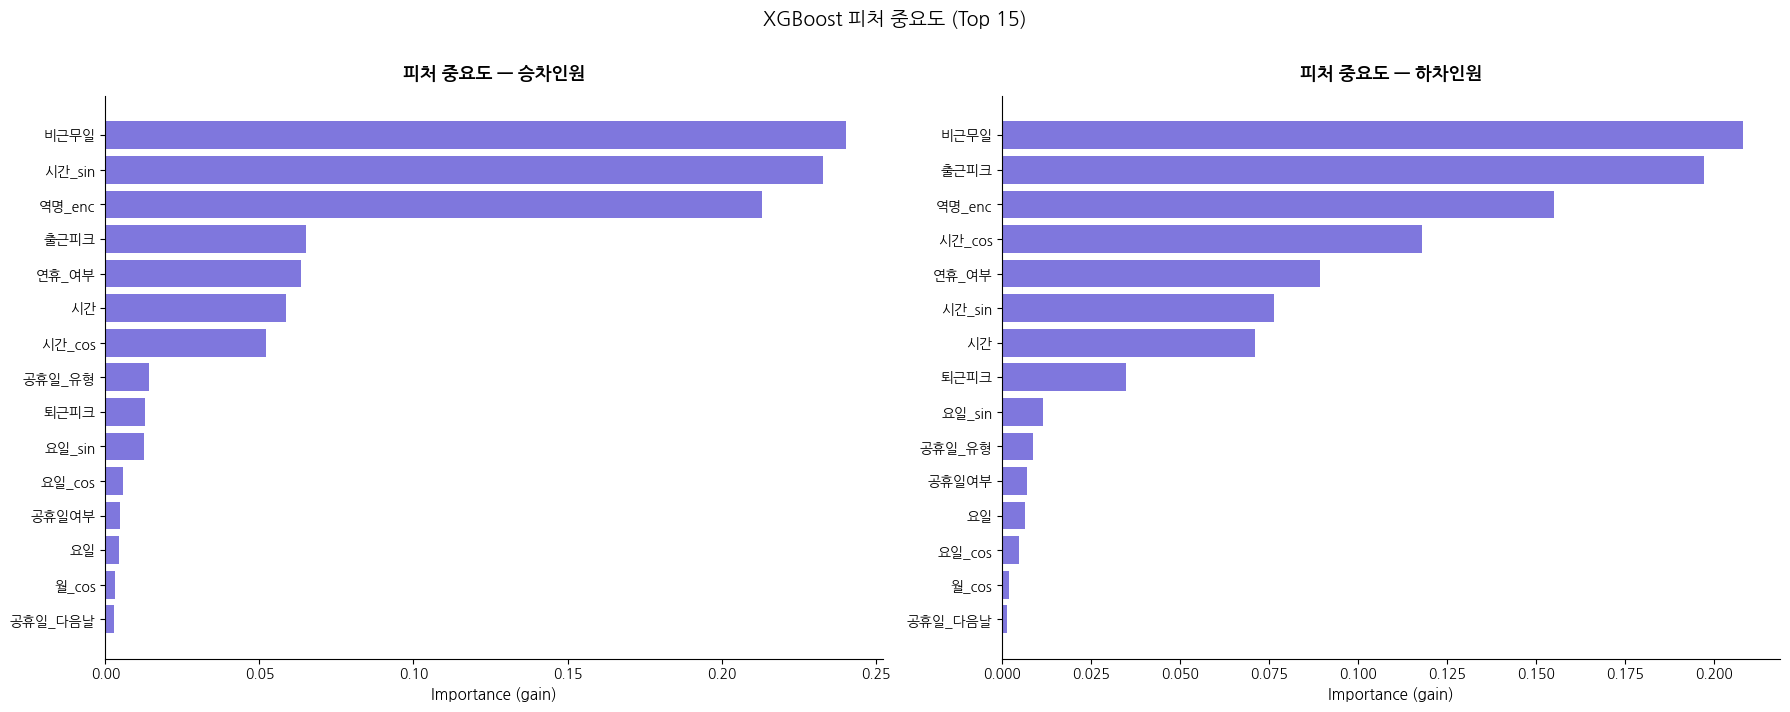

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, estimator, label in zip(axes, [model_board, model_alight], TARGET_COLS):
    imp        = estimator.feature_importances_
    sorted_idx = np.argsort(imp)[::-1]
    top_n      = 15

    ax.barh(
        [FEATURE_COLS[i] for i in sorted_idx[:top_n]][::-1],
        imp[sorted_idx[:top_n]][::-1],
        color="#7F77DD", edgecolor="none",
    )
    ax.set_title(f"피처 중요도 — {label}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Importance (gain)", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=10)

plt.suptitle("XGBoost 피처 중요도 (Top 15)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. 예측값 vs 실제값 시각화

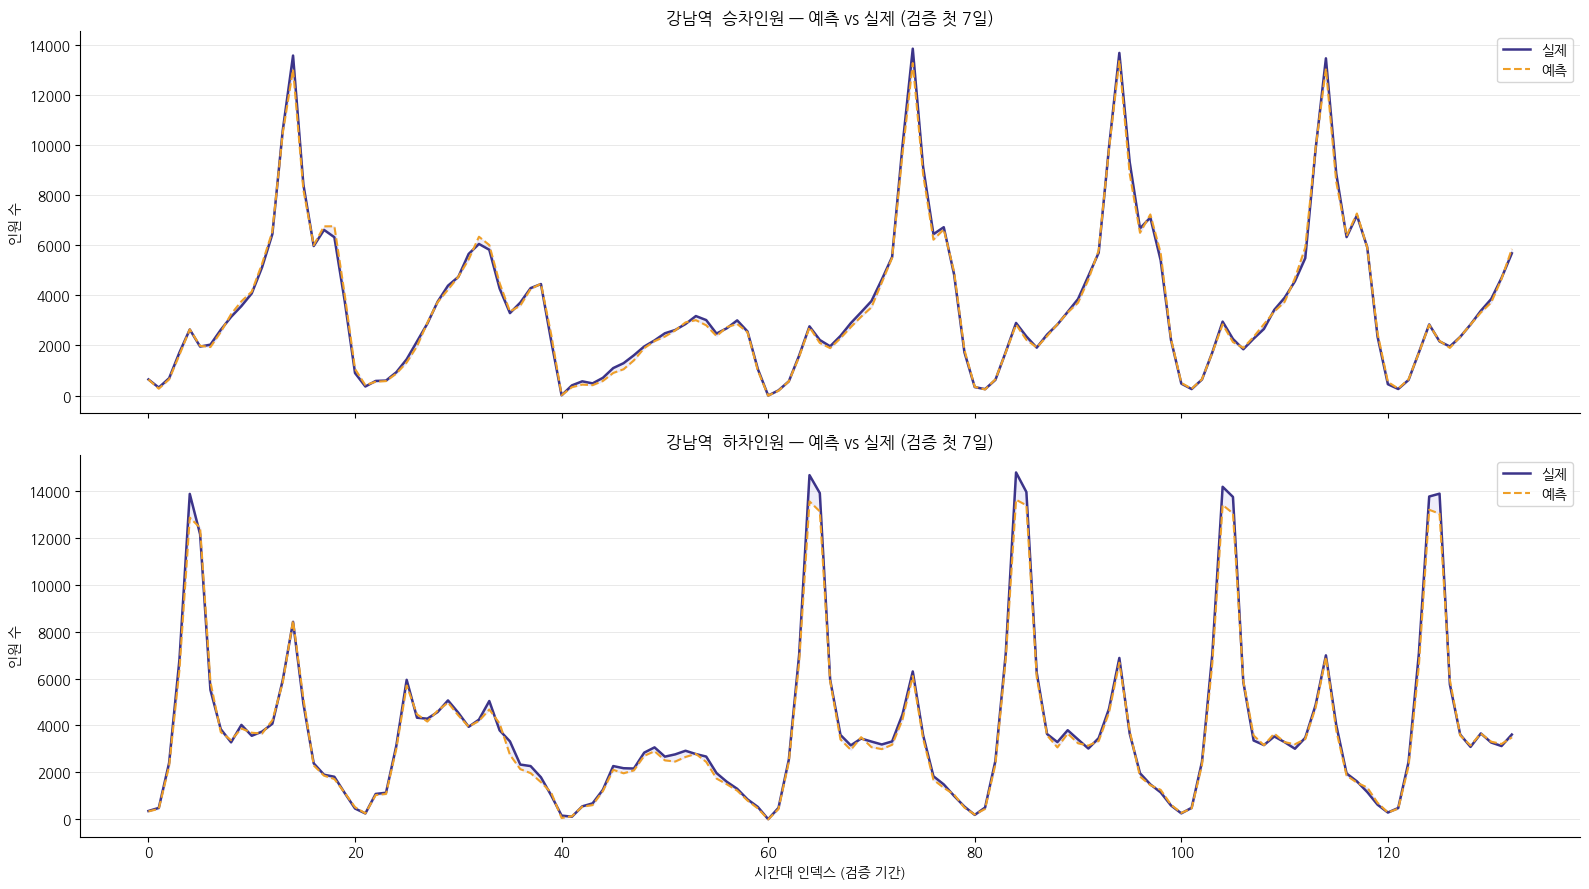

In [16]:
TARGET_STATION = "강남"
if TARGET_STATION not in le_station.classes_:
    TARGET_STATION = le_station.classes_[0]

stn_enc   = le_station.transform([TARGET_STATION])[0]
mask      = valid_df["역명_enc"] == stn_enc
DAYS_SHOW = 7
cut       = min(mask.sum(), DAYS_SHOW * 19)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

for ax, col in zip(axes, TARGET_COLS):
    actual = y_valid.loc[mask, col].values[:cut]
    pred   = y_pred.loc[mask,  col].values[:cut]

    ax.plot(actual, label="실제", color="#3C3489", linewidth=1.8)
    ax.plot(pred,   label="예측", color="#EF9F27", linewidth=1.5, linestyle="--")
    ax.fill_between(range(len(actual)), actual, pred, alpha=0.12, color="#7F77DD")
    ax.set_title(f"{TARGET_STATION}역  {col} — 예측 vs 실제 (검증 첫 {DAYS_SHOW}일)", fontsize=12)
    ax.set_ylabel("인원 수", fontsize=10)
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, alpha=0.4)

axes[-1].set_xlabel("시간대 인덱스 (검증 기간)", fontsize=10)
plt.tight_layout()
plt.savefig(f"prediction_{TARGET_STATION}.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. 시간대별 평균 패턴 분석

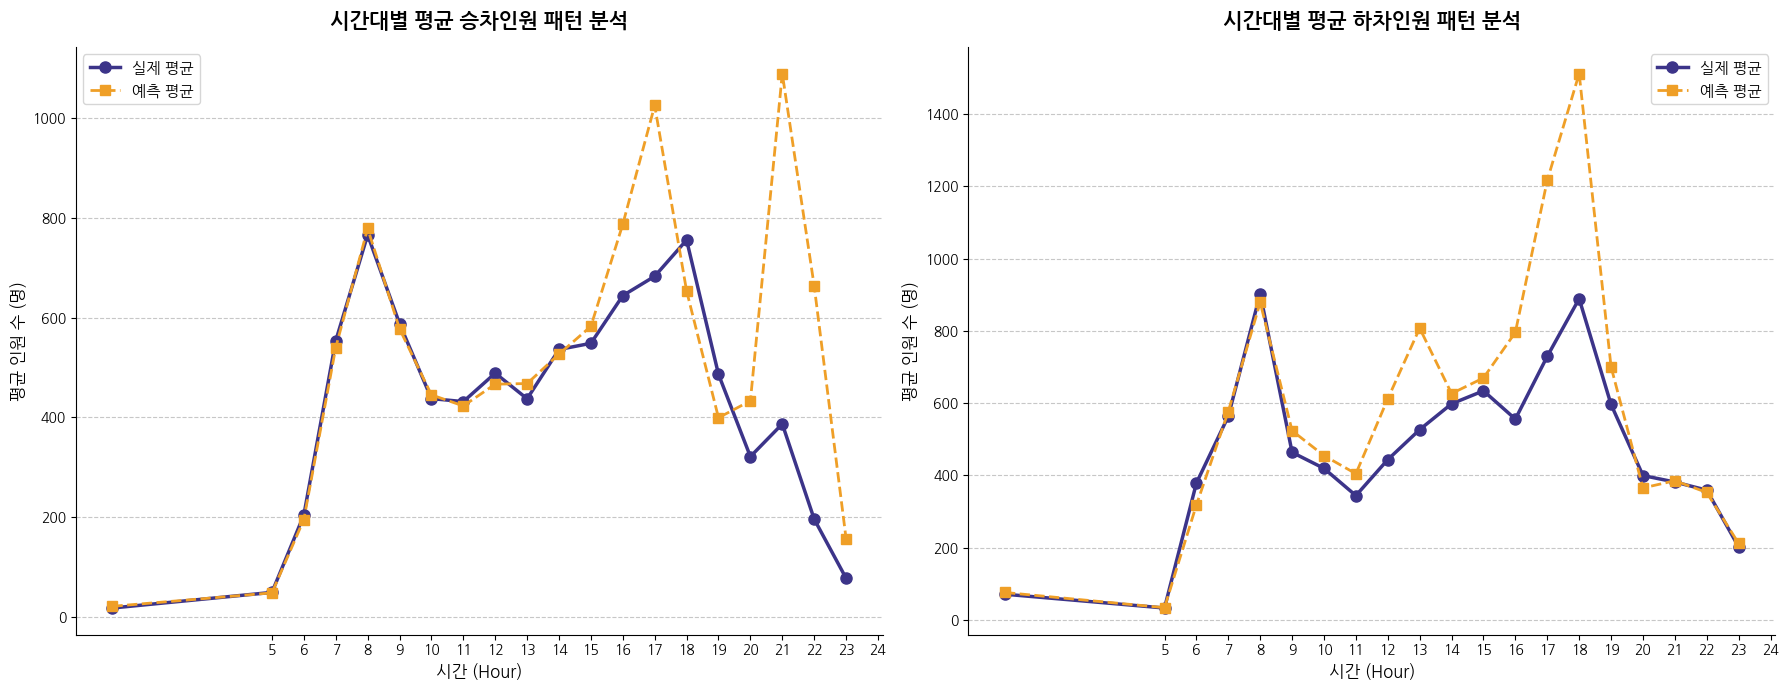

   시간대별 평균 예측 오차율 (MAPE)


시간,0,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
승차_MAPE(%),210.6,20.17,12.65,12.56,9.59,8.77,8.62,9.10,9.43,10.39,12.01,12.45,12.49,11.58,12.28,15.00,16.32,24.46,31.61,38.18
하차_MAPE(%),116.1,35.69,15.15,14.93,13.42,14.74,14.12,12.59,13.31,12.73,12.48,13.34,14.36,12.29,11.93,12.01,11.68,9.91,11.93,15.05


In [17]:
target_sample = sample[sample['역명'] == '종합운동장']
hourly_pattern = target_sample.groupby('시간')[['실제_승차', '예측_승차', '실제_하차', '예측_하차']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_configs = [
    ('실제_승차', '예측_승차', '승차인원', '#3C3489', '#EF9F27'),
    ('실제_하차', '예측_하차', '하차인원', '#3C3489', '#EF9F27')
]
for i, (actual_col, pred_col, title, actual_color, pred_color) in enumerate(plot_configs):
    ax = axes[i]
    ax.plot(hourly_pattern['시간'], hourly_pattern[actual_col], 'o-',
            label='실제 평균', color=actual_color, linewidth=2.5, markersize=8)
    ax.plot(hourly_pattern['시간'], hourly_pattern[pred_col], 's--',
            label='예측 평균', color=pred_color, linewidth=2, markersize=7)
    ax.set_title(f'시간대별 평균 {title} 패턴 분석', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('시간 (Hour)', fontsize=12)
    ax.set_ylabel('평균 인원 수 (명)', fontsize=12)
    ax.set_xticks(range(5, 25))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("="*50)
print("   시간대별 평균 예측 오차율 (MAPE)")
print("="*50)
hourly_mape = sample.groupby('시간').apply(lambda x: mape(x['실제_승차'], x['예측_승차'])).reset_index()
hourly_mape.columns = ['시간', '승차_MAPE(%)']
hourly_mape['하차_MAPE(%)'] = sample.groupby('시간').apply(lambda x: mape(x['실제_하차'], x['예측_하차'])).values
display(hourly_mape.round(2).set_index('시간').T)


## 13. 특정 날짜 & 역 상세 비교

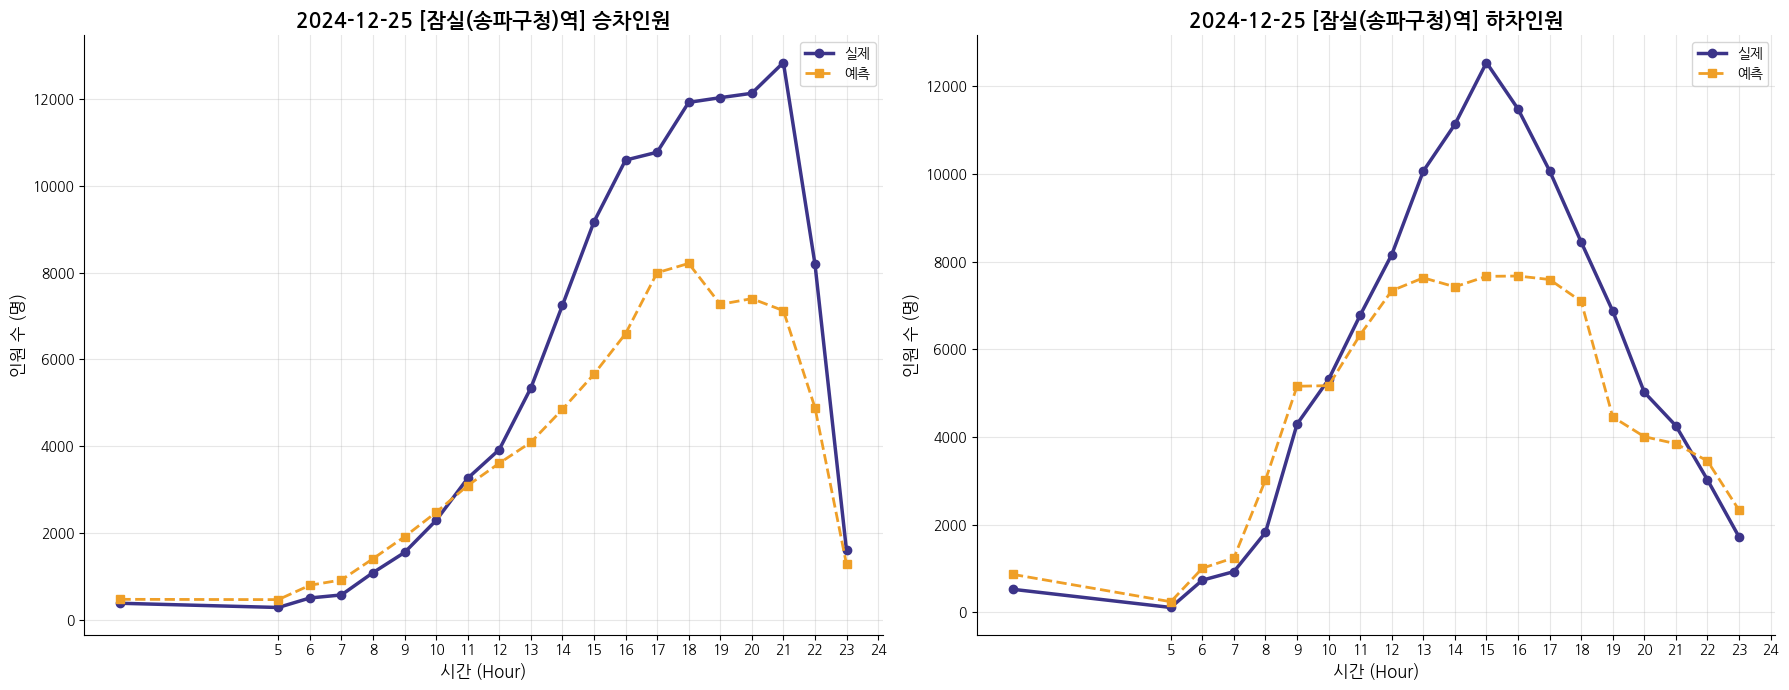

--- 2024-12-25 잠실(송파구청)역 예측 요약 ---
승차 MAPE: 32.73%
하차 MAPE: 32.12%


In [18]:
target_date    = "2024-12-25"
target_station = "잠실(송파구청)"

day_data = sample[(sample['날짜'] == target_date) & (sample['역명'] == target_station)].sort_values('시간')

if len(day_data) == 0:
    print(f"데이터가 없습니다. 날짜({target_date})나 역명({target_station})을 확인해주세요.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    titles      = ['승차인원', '하차인원']
    actual_cols = ['실제_승차', '실제_하차']
    pred_cols   = ['예측_승차', '예측_하차']

    for i in range(2):
        ax = axes[i]
        ax.plot(day_data['시간'], day_data[actual_cols[i]], 'o-', label='실제', color='#3C3489', linewidth=2.5)
        ax.plot(day_data['시간'], day_data[pred_cols[i]],   's--', label='예측', color='#EF9F27', linewidth=2)
        ax.set_title(f"{target_date} [{target_station}역] {titles[i]}", fontsize=15, fontweight='bold')
        ax.set_xlabel("시간 (Hour)", fontsize=12)
        ax.set_ylabel("인원 수 (명)", fontsize=12)
        ax.set_xticks(range(5, 25))
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    m_board  = mape(day_data['실제_승차'], day_data['예측_승차'])
    m_alight = mape(day_data['실제_하차'], day_data['예측_하차'])
    print(f"--- {target_date} {target_station}역 예측 요약 ---")
    print(f"승차 MAPE: {m_board:.2f}%")
    print(f"하차 MAPE: {m_alight:.2f}%")


## 14. 역별 MAPE 비교 (승차인원 기준)

MAPE 낮은 역 TOP 10 (예측 정확도 높음)


,역명,MAPE(%)
6,낙성대(강감찬),7.34
8,대림(구로구청),8.64
14,봉천,9.02
25,신대방,9.20
33,역삼,9.34
5,구의(광진구청),9.68
24,신당,9.81
49,홍대입구,9.83
17,상왕십리,11.87
34,영등포구청,12.16


MAPE 높은 역 TOP 10 (예측 어려운 역)


,역명,MAPE(%)
15,사당,32.82
28,신설동,33.06
10,동대문역사문화공원(DDP),34.55
36,용답,36.89
40,을지로입구,41.62
37,용두(동대문구청),49.20
30,신촌,58.35
45,종합운동장,78.16
23,신답,90.14
9,도림천,90.31


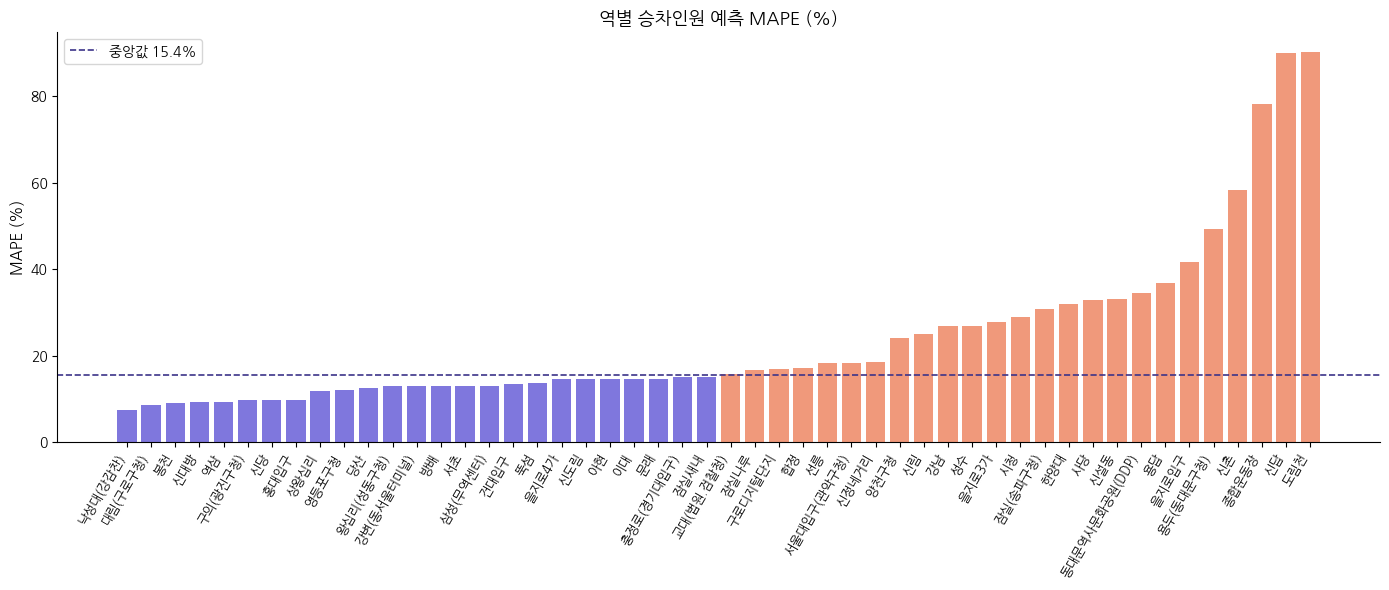

In [19]:
station_mapes = []
for stn in le_station.classes_:
    stn_enc = le_station.transform([stn])[0]
    m       = valid_df["역명_enc"] == stn_enc
    if m.sum() == 0:
        continue
    m_val = mape(y_valid.loc[m, "승차인원"], y_pred.loc[m, "승차인원"])
    station_mapes.append({"역명": stn, "MAPE(%)": round(m_val, 2)})

mape_df = pd.DataFrame(station_mapes).sort_values("MAPE(%)")
print("MAPE 낮은 역 TOP 10 (예측 정확도 높음)")
display(mape_df.head(10))
print("MAPE 높은 역 TOP 10 (예측 어려운 역)")
display(mape_df.tail(10))

fig, ax = plt.subplots(figsize=(14, 6))
colors  = ["#7F77DD" if v < mape_df["MAPE(%)"].median() else "#F0997B"
           for v in mape_df["MAPE(%)"]]
ax.bar(mape_df["역명"], mape_df["MAPE(%)"], color=colors, edgecolor="none")
ax.axhline(mape_df["MAPE(%)"].median(), color="#3C3489", linestyle="--",
           linewidth=1.2, label=f"중앙값 {mape_df['MAPE(%)'].median():.1f}%")
ax.set_title("역별 승차인원 예측 MAPE (%)", fontsize=13)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_xticklabels(mape_df["역명"], rotation=60, ha="right", fontsize=9)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("station_mape.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. SHAP 날씨 영향도 분석

> SHAP(SHapley Additive exPlanations)은 각 피처가 개별 예측에 얼마나, 어느 방향으로 기여했는지를 수치로 나타냅니다.
> - **양수(+)**: 해당 피처가 승하차 인원을 높이는 방향으로 기여
> - **음수(−)**: 낮추는 방향으로 기여


### 15-1. SHAP 값 계산

In [20]:
SHAP_SAMPLE = min(5000, len(X_valid))
X_shap      = X_valid.sample(SHAP_SAMPLE, random_state=42)

print(f"SHAP 계산 샘플: {SHAP_SAMPLE:,}행")

explainer_board  = shap.TreeExplainer(model_board)
explainer_alight = shap.TreeExplainer(model_alight)

shap_board  = explainer_board.shap_values(X_shap)
shap_alight = explainer_alight.shap_values(X_shap)

print("SHAP 계산 완료")


SHAP 계산 샘플: 5,000행
SHAP 계산 완료


### 15-2. 전체 피처 SHAP 요약 플롯 (승차인원 기준)

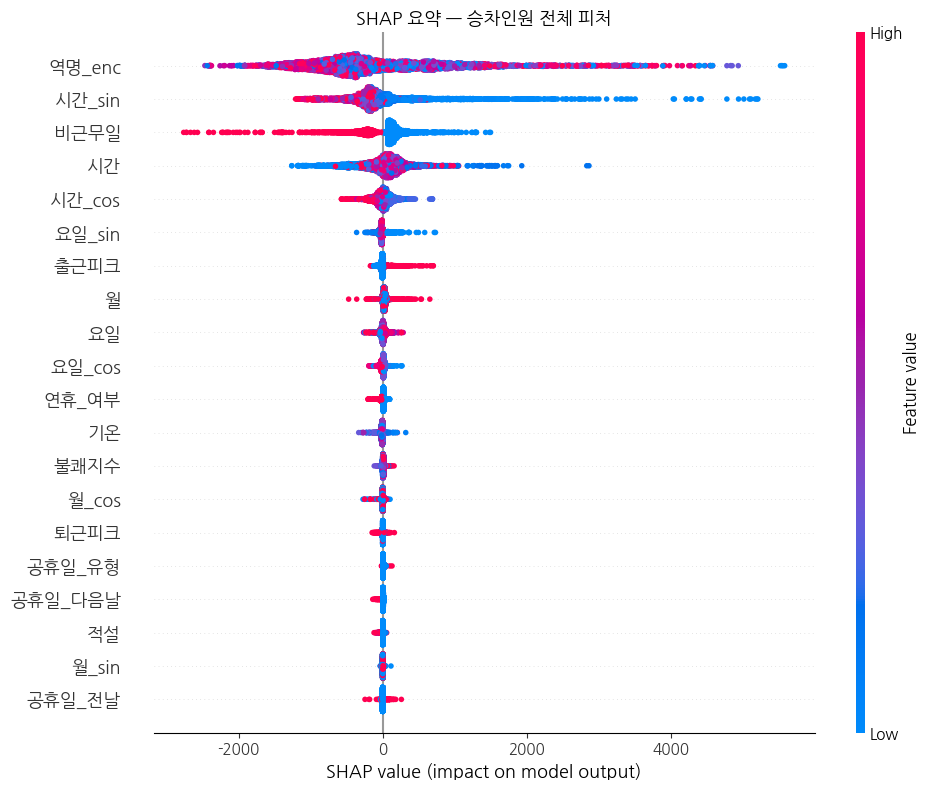

In [21]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_board,
    X_shap,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(10, 8),
)
plt.title("SHAP 요약 — 승차인원 전체 피처", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_board.png", dpi=150, bbox_inches="tight")
plt.show()


### 15-3. 날씨 피처 SHAP 영향도 비교 (승차 vs 하차)

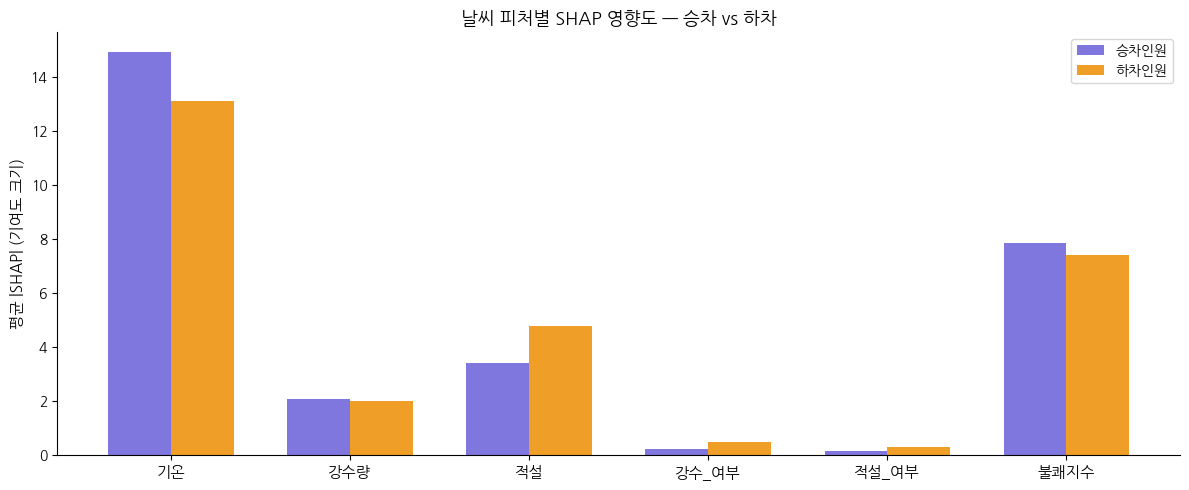

날씨 피처 영향도 순위 (승차인원 기준):
  기온        : 14.92
  불쾌지수      : 7.87
  적설        : 3.41
  강수량       : 2.07
  강수_여부     : 0.24
  적설_여부     : 0.17


In [22]:
WEATHER_COLS = ["기온", "강수량", "적설", "강수_여부", "적설_여부", "불쾌지수"]
w_idx        = [FEATURE_COLS.index(c) for c in WEATHER_COLS]

mean_shap_board  = np.abs(shap_board[:,  w_idx]).mean(axis=0)
mean_shap_alight = np.abs(shap_alight[:, w_idx]).mean(axis=0)

x     = np.arange(len(WEATHER_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, mean_shap_board,  width, label="승차인원", color="#7F77DD", edgecolor="none")
ax.bar(x + width/2, mean_shap_alight, width, label="하차인원", color="#EF9F27", edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(WEATHER_COLS, fontsize=11)
ax.set_ylabel("평균 |SHAP| (기여도 크기)", fontsize=11)
ax.set_title("날씨 피처별 SHAP 영향도 — 승차 vs 하차", fontsize=13)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("shap_weather_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("날씨 피처 영향도 순위 (승차인원 기준):")
for col, val in sorted(zip(WEATHER_COLS, mean_shap_board), key=lambda x: -x[1]):
    print(f"  {col:<10}: {val:,.2f}")


### 15-4. 시간대별 날씨 SHAP 히트맵

> 각 시간대에서 날씨 피처가 승차인원에 미치는 평균 영향도를 히트맵으로 시각화합니다.
> - 색이 진할수록 해당 시간대에 날씨 영향이 큼


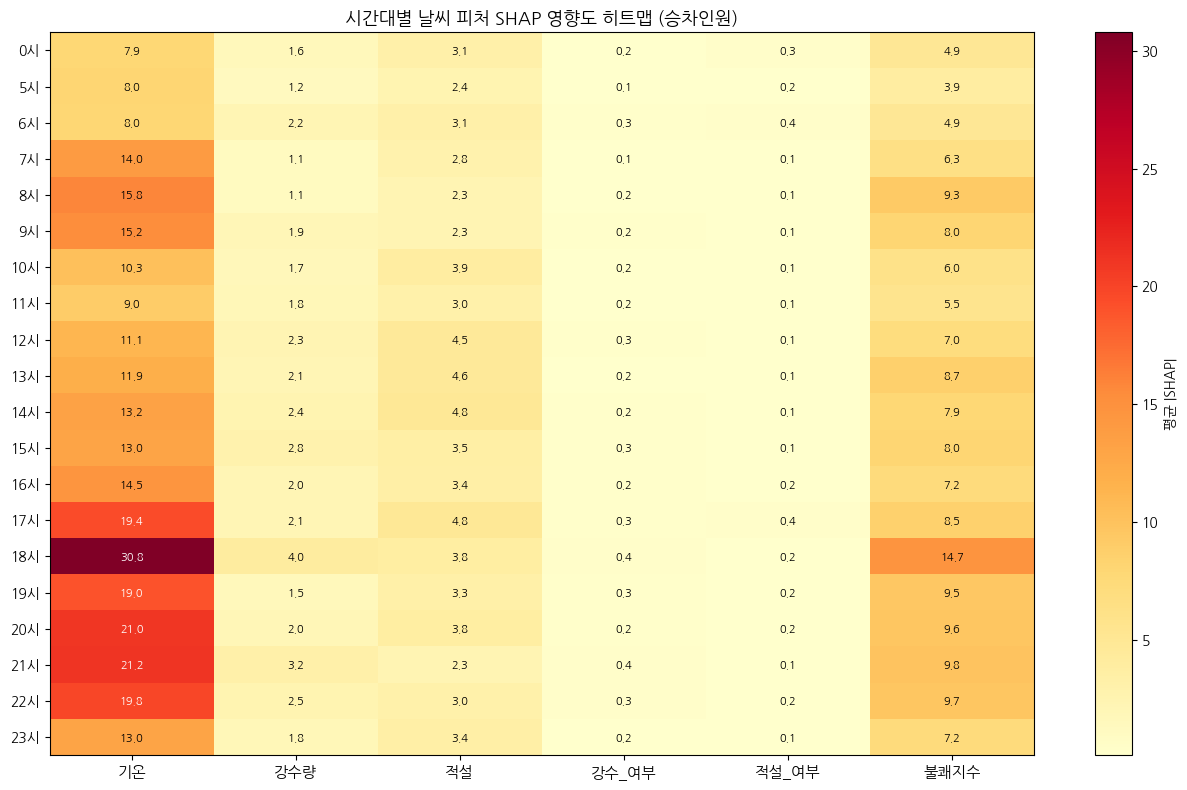

In [23]:
X_shap_with_hour = X_shap.copy()
hours_list       = sorted(X_shap_with_hour["시간"].unique())

heatmap_data = np.zeros((len(hours_list), len(WEATHER_COLS)))
for i, hr in enumerate(hours_list):
    mask_hr = X_shap_with_hour["시간"] == hr
    if mask_hr.sum() == 0:
        continue
    heatmap_data[i] = np.abs(shap_board[mask_hr.values][:, w_idx]).mean(axis=0)

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=[f"{h}시" for h in hours_list],
    columns=WEATHER_COLS,
)

fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(WEATHER_COLS)))
ax.set_xticklabels(WEATHER_COLS, fontsize=11)
ax.set_yticks(range(len(hours_list)))
ax.set_yticklabels([f"{h}시" for h in hours_list], fontsize=10)
ax.set_title("시간대별 날씨 피처 SHAP 영향도 히트맵 (승차인원)", fontsize=13)
plt.colorbar(im, ax=ax, label="평균 |SHAP|")

for i in range(len(hours_list)):
    for j in range(len(WEATHER_COLS)):
        ax.text(j, i, f"{heatmap_data[i,j]:.1f}",
                ha="center", va="center", fontsize=8,
                color="white" if heatmap_data[i,j] > heatmap_data.max()*0.6 else "black")

plt.tight_layout()
plt.savefig("shap_heatmap_hourly.png", dpi=150, bbox_inches="tight")
plt.show()


### 15-5. 강수량 SHAP Dependence Plot

> 강수량 값에 따라 SHAP 기여도가 어떻게 달라지는지 시각화합니다.
> 색깔은 기온 값을 나타냅니다.


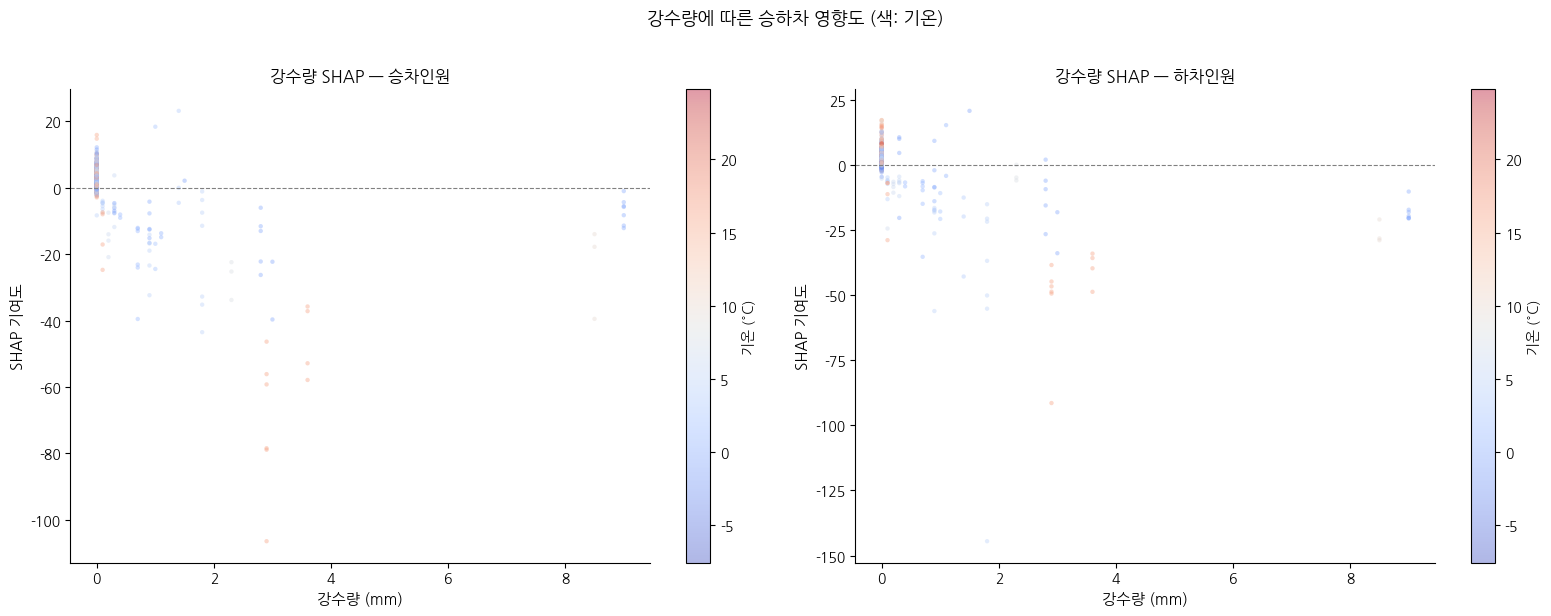

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, shap_vals, label in zip(axes, [shap_board, shap_alight], TARGET_COLS):
    rain_idx = FEATURE_COLS.index("강수량")

    sc = ax.scatter(
        X_shap["강수량"],
        shap_vals[:, rain_idx],
        c=X_shap["기온"],
        cmap="coolwarm",
        alpha=0.4,
        s=10,
        edgecolors="none",
    )
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("강수량 (mm)", fontsize=11)
    ax.set_ylabel("SHAP 기여도", fontsize=11)
    ax.set_title(f"강수량 SHAP — {label}", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    plt.colorbar(sc, ax=ax, label="기온 (°C)")

plt.suptitle("강수량에 따른 승하차 영향도 (색: 기온)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("shap_dependence_rain.png", dpi=150, bbox_inches="tight")
plt.show()


## 16. 모델 저장

In [25]:
os.makedirs("models", exist_ok=True)
joblib.dump(model_board,    "models/xgb_board_model.pkl")
joblib.dump(model_alight,   "models/xgb_alight_model.pkl")
joblib.dump(le_station,     "models/label_encoder_station.pkl")
joblib.dump(study_board,    "models/optuna_study_board.pkl")    # Optuna 탐색 결과 저장
joblib.dump(study_alight,   "models/optuna_study_alight.pkl")   # Optuna 탐색 결과 저장

print("저장 완료")
print("  models/xgb_board_model.pkl")
print("  models/xgb_alight_model.pkl")
print("  models/label_encoder_station.pkl")
print("  models/optuna_study_board.pkl    ← Optuna 탐색 결과 (재사용 가능)")
print("  models/optuna_study_alight.pkl   ← Optuna 탐색 결과 (재사용 가능)")


저장 완료
  models/xgb_board_model.pkl
  models/xgb_alight_model.pkl
  models/label_encoder_station.pkl
  models/optuna_study_board.pkl    ← Optuna 탐색 결과 (재사용 가능)
  models/optuna_study_alight.pkl   ← Optuna 탐색 결과 (재사용 가능)


## 17. 단일 예측 추론 함수

In [26]:
import holidays as hd

def predict_single(station, date_str, hour, temp, rain=0.0, snow=0.0):
    date    = pd.Timestamp(date_str)
    kr_hols = hd.KR(years=date.year)
    is_hol  = int(date.date() in kr_hols)
    stn_enc = le_station.transform([station])[0]

    # 공휴일 유형 계산
    def get_hol_type(d):
        if d.date() not in kr_hols:
            return 0
        name = kr_hols.get(d.date(), "")
        if any(k in name for k in ["Korean New Year","Chuseok","preceding Korean","preceding Chuseok","second day of Korean","second day of Chuseok"]):
            return 3
        elif any(k in name for k in ["Children","Christmas","Buddha"]):
            return 2
        return 1

    # 연휴 여부 계산
    prev_d  = date - pd.Timedelta(days=1)
    next_d  = date + pd.Timedelta(days=1)
    prev_off = (prev_d.weekday() >= 5) or (prev_d.date() in kr_hols)
    next_off = (next_d.weekday() >= 5) or (next_d.date() in kr_hols)
    is_off   = (date.weekday() >= 5) or bool(is_hol)

    row = {
        "역명_enc":      stn_enc,
        "시간":          hour,
        "시간_sin":      np.sin(2 * np.pi * hour / 24),
        "시간_cos":      np.cos(2 * np.pi * hour / 24),
        "요일":          date.weekday(),
        "요일_sin":      np.sin(2 * np.pi * date.weekday() / 7),
        "요일_cos":      np.cos(2 * np.pi * date.weekday() / 7),
        "월":            date.month,
        "월_sin":        np.sin(2 * np.pi * date.month / 12),
        "월_cos":        np.cos(2 * np.pi * date.month / 12),
        "공휴일여부":     is_hol,
        "비근무일":       int(date.weekday() >= 5 or bool(is_hol)),
        "출근피크":       int(hour in [7, 8, 9]),
        "퇴근피크":       int(hour in [18, 19, 20]),
        "기온":           temp,
        "강수량":         rain,
        "적설":           snow,
        "강수_여부":      int(rain > 0),
        "적설_여부":      int(snow > 0),
        "불쾌지수":       round(9/5*temp - 0.55*(1-int(rain>0)*0.8)*(9/5*temp-26)+32, 2),
        # ── 추가된 4개 피처 ──
        "공휴일_유형":    get_hol_type(date),
        "연휴_여부":      int(is_off and (prev_off or next_off)),
        "공휴일_전날":    int((date + pd.Timedelta(days=1)).date() in kr_hols),
        "공휴일_다음날":  int((date - pd.Timedelta(days=1)).date() in kr_hols),
    }

    X           = pd.DataFrame([row])[FEATURE_COLS]
    pred_board  = int(np.clip(model_board.predict(X),  0, None)[0])
    pred_alight = int(np.clip(model_alight.predict(X), 0, None)[0])

    return {
        "역명":          station,
        "날짜":          date_str,
        "시간":          f"{hour}시",
        "예측_승차인원": pred_board,
        "예측_하차인원": pred_alight,
    }


# ── 사용 예시 ──
examples = [
    ("강남", "2025-01-10",  9,  3.0, 0.0, 0.0),
    ("강남", "2025-01-10", 18,  3.0, 0.0, 0.0),
    ("강남", "2025-01-11", 14,  1.5, 5.2, 0.0),
    ("강남", "2025-01-01", 12, -2.0, 0.0, 3.0),
]

print(f"{'역명':<8} {'날짜':<12} {'시간':<6} {'예측승차':>8} {'예측하차':>8}")
print("-" * 50)
for args in examples:
    r = predict_single(*args)
    print(f"{r['역명']:<8} {r['날짜']:<12} {r['시간']:<6} {r['예측_승차인원']:>8,} {r['예측_하차인원']:>8,}")

역명       날짜           시간         예측승차     예측하차
--------------------------------------------------
강남       2025-01-10   9시        1,934   13,118
강남       2025-01-10   18시      13,664    9,106
강남       2025-01-11   14시       4,723    4,551
강남       2025-01-01   12시       1,835    2,554


In [28]:
import shutil
from google.colab import files

# 5개 전부 zip으로 묶어서 다운로드
shutil.make_archive("subway_models", "zip", "models")
files.download("subway_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import shutil

shutil.copytree("models", "/content/drive/MyDrive/subway_models",
                dirs_exist_ok=True)
print("Drive 백업 완료")

Drive 백업 완료
